In [1]:
import mysql.connector
import pandas as pd
from matplotlib import pyplot as plt

import bt4301

bt4301.set_default_pandas_options(max_columns=50)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

In [5]:
db_datawarehouse = mysql.connector.connect(
    host='localhost',
    user='bt4301',
    passwd='password',
    database='datawarehouse'
)


## **Business Question**

Can we predict the expected sales demand and revenue for each product across stores/customer segments in the next sales period using historical sales transactions and related dimension data?

## **Business Challenge / Opportunity**

The data warehouse contains a detailed fact_store_sales table linked with dimensions such as product, customer/store, time, and salesperson. This gives the business a strong foundation to understand not only what was sold, but also where, when, by whom, and to which customer/store type.

A key business challenge is that sales demand can vary across:

product categories and subcategories
stores and customer territories
sales periods such as month, quarter, weekday, or weekend
salesperson performance and customer buying behaviour
pricing, discounts, and product cost/margin patterns

Without predictive analytics, the company mainly reacts to past sales. This can lead to poor inventory planning, missed sales opportunities, overstocking of slow moving products, and inefficient sales targeting.

By predicting future product level demand or revenue, the business can:

plan inventory more accurately
identify high demand products in advance
improve store level stock allocation
support sales teams with better forecasts
improve revenue and profit margin planning

So, the opportunity is to move from descriptive reporting to forward looking sales planning.

In [8]:
str_sql = '''
WITH monthly_sales AS (
    SELECT
        p.product_key,
        p.product_id,
        p.product_name,
        p.product_category_name,
        p.product_subcategory_name,
        p.product_model_name,
        p.color,
        p.size,
        p.weight,
        p.standard_cost,
        p.list_price,

        c.customer_key,
        c.customer_id,
        c.store_id,
        c.store_name,
        c.territory_id,

        sp.salesperson_key,
        sp.salesperson_id,
        sp.sales_quota,
        sp.bonus,
        sp.commission_pct,
        sp.sales_ytd,
        sp.sales_last_year,

        t.year_num,
        t.month_num,
        t.quarter_num,

        SUM(f.order_qty) AS current_month_order_qty,
        SUM(f.gross_amount) AS current_month_gross_sales,
        SUM(f.discount_amount) AS current_month_discount_amount,
        SUM(f.net_amount) AS current_month_net_sales,
        SUM(f.margin_amount) AS current_month_margin_amount,

        AVG(f.unit_price) AS avg_unit_price,
        AVG(f.unit_price_discount) AS avg_unit_price_discount,

        COUNT(DISTINCT f.sales_order_id) AS number_of_orders,
        COUNT(*) AS number_of_order_lines

    FROM fact_store_sales f
    JOIN dim_product p
        ON f.product_key = p.product_key
    JOIN dim_store_customer c
        ON f.customer_key = c.customer_key
    JOIN dim_time t
        ON f.order_date_key = t.time_key
    JOIN dim_salesperson sp
        ON f.salesperson_key = sp.salesperson_key

    GROUP BY
        p.product_key,
        p.product_id,
        p.product_name,
        p.product_category_name,
        p.product_subcategory_name,
        p.product_model_name,
        p.color,
        p.size,
        p.weight,
        p.standard_cost,
        p.list_price,

        c.customer_key,
        c.customer_id,
        c.store_id,
        c.store_name,
        c.territory_id,

        sp.salesperson_key,
        sp.salesperson_id,
        sp.sales_quota,
        sp.bonus,
        sp.commission_pct,
        sp.sales_ytd,
        sp.sales_last_year,

        t.year_num,
        t.month_num,
        t.quarter_num
),

ml_dataset AS (
    SELECT
        monthly_sales.*,

        LEAD(current_month_net_sales) OVER (
            PARTITION BY product_key, store_id
            ORDER BY year_num, month_num
        ) AS next_period_net_sales

    FROM monthly_sales
)

SELECT *
FROM ml_dataset
WHERE next_period_net_sales IS NOT NULL
ORDER BY product_id, store_id, year_num, month_num;
'''
df = pd.read_sql(sql=str_sql, con=db_datawarehouse)

print('Rows loaded:', len(df))
df.head()

/tmp/ipykernel_8279/819202342.py:105: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(sql=str_sql, con=db_datawarehouse)


Rows loaded: 40394


,product_key,product_id,product_name,product_category_name,product_subcategory_name,product_model_name,color,size,weight,standard_cost,list_price,customer_key,customer_id,store_id,store_name,territory_id,salesperson_key,salesperson_id,sales_quota,bonus,commission_pct,sales_ytd,sales_last_year,year_num,month_num,quarter_num,current_month_order_qty,current_month_gross_sales,current_month_discount_amount,current_month_net_sales,current_month_margin_amount,avg_unit_price,avg_unit_price_discount,number_of_orders,number_of_order_lines,next_period_net_sales
0,1,707,"Sport-100 Helmet, Red",Accessories,Helmets,Sport-100,Red,NaN,NaN,13.09,34.99,114,29484,292,Next-Door Bike Store,5,6,279,300000.00,6700.00,0.01,2315185.61,1849640.94,2006,9,3,4.00,80.75,0.00,80.75,28.40,20.19,0.00,1,1,80.75
1,1,707,"Sport-100 Helmet, Red",Accessories,Helmets,Sport-100,Red,NaN,NaN,13.09,34.99,114,29484,292,Next-Door Bike Store,5,6,279,300000.00,6700.00,0.01,2315185.61,1849640.94,2006,12,4,4.00,80.75,0.00,80.75,28.40,20.19,0.00,1,1,40.37
2,1,707,"Sport-100 Helmet, Red",Accessories,Helmets,Sport-100,Red,NaN,NaN,13.09,34.99,536,29485,294,Professional Sales and Service,4,3,276,250000.00,2000.00,0.01,4251368.55,1439156.03,2007,9,3,6.00,125.96,0.00,125.96,47.45,20.99,0.00,1,1,62.98
3,1,707,"Sport-100 Helmet, Red",Accessories,Helmets,Sport-100,Red,NaN,NaN,13.09,34.99,536,29485,294,Professional Sales and Service,4,3,276,250000.00,2000.00,0.01,4251368.55,1439156.03,2007,12,4,3.00,62.98,0.00,62.98,23.72,20.99,0.00,1,1,62.98
4,1,707,"Sport-100 Helmet, Red",Accessories,Helmets,Sport-100,Red,NaN,NaN,13.09,34.99,115,29486,296,Riders Company,3,4,277,250000.00,2500.00,0.01,3189418.37,1997186.20,2005,12,4,3.00,60.56,0.00,60.56,21.30,20.19,0.00,1,1,80.75


In [9]:
df.describe()

,product_key,product_id,weight,standard_cost,list_price,customer_key,customer_id,store_id,territory_id,salesperson_key,salesperson_id,sales_quota,bonus,commission_pct,sales_ytd,sales_last_year,year_num,month_num,quarter_num,current_month_order_qty,current_month_gross_sales,current_month_discount_amount,current_month_net_sales,current_month_margin_amount,avg_unit_price,avg_unit_price_discount,number_of_orders,number_of_order_lines,next_period_net_sales
count,40394.00,40394.00,26187.00,40394.00,40394.00,40394.00,40394.00,40394.00,40394.00,40394.00,40394.00,39320.00,40394.00,40394.00,40394.00,40394.00,40394.00,40394.00,40394.00,40394.00,40394.00,40394.00,40394.00,40394.00,40394.00,40394.00,40394.00,40394.00,40394.00
mean,99.19,826.24,44.88,470.35,797.86,252.68,29802.74,1048.36,4.56,14.96,280.70,262015.51,3470.19,0.01,2911047.89,1714713.12,2006.60,7.55,2.81,3.75,1446.02,8.28,1437.74,-43.42,458.97,0.00,1.00,1.00,1401.14
std,73.37,86.34,127.10,534.97,902.36,168.63,186.39,486.95,2.41,17.58,5.01,21363.86,1850.36,0.00,1036326.84,490307.51,0.81,3.53,1.15,3.19,2261.05,79.94,2242.53,362.75,523.38,0.03,0.01,0.01,2184.34
min,1.00,707.00,2.12,0.86,2.29,1.00,29484.00,292.00,1.00,2.00,274.00,250000.00,0.00,0.00,172524.45,0.00,2005.00,1.00,1.00,1.00,1.37,0.00,1.37,-15099.75,1.33,0.00,1.00,1.00,1.37
25%,33.00,761.00,3.10,30.93,59.99,110.00,29641.00,652.00,3.00,4.00,276.00,250000.00,2000.00,0.01,2315185.61,1620276.90,2006.00,4.00,2.00,2.00,143.98,0.00,143.98,-67.25,33.77,0.00,1.00,1.00,134.98
50%,84.00,801.00,19.42,294.58,539.99,245.00,29793.00,978.00,4.00,6.00,279.00,250000.00,3550.00,0.01,3121616.32,1750406.48,2007.00,8.00,3.00,3.00,566.46,0.00,554.12,-3.47,323.99,0.00,1.00,1.00,477.39
75%,146.00,883.00,25.13,713.08,1120.49,365.00,29956.00,1334.00,6.00,36.00,284.00,250000.00,5000.00,0.01,3763178.18,1997186.20,2007.00,11.00,4.00,5.00,1749.59,0.00,1749.59,41.06,672.29,0.00,1.00,1.00,1677.84
max,248.00,999.00,1050.00,2171.29,3578.27,628.00,30118.00,1994.00,10.00,70.00,290.00,300000.00,6700.00,0.02,4251368.55,2396539.76,2008.00,12.00,4.00,40.00,30992.91,4005.24,27893.62,1278.40,2146.96,0.30,2.00,2.00,27893.62


## **Proposed Analytics Solution**

The solution is to build a supervised machine learning regression model that predicts future sales demand or revenue at a product store period level.

## Dependent Variable / Target Variable

The main dependent variable can be:

next_period_net_sales

or alternatively:

next_period_order_qty

For example, the data can be aggregated from fact_store_sales into a monthly product store dataset:

Product	Store / Customer	Month	Total Quantity Sold	Net Sales	Margin

Then the model predicts the next period’s sales value or quantity.

A suitable target variable would be:

Predicted net sales amount for a product in a store/customer segment in the next month.

This makes the problem a regression prediction problem, because the output is a continuous numerical value.

In [13]:
import pandas as pd
import numpy as np

# -----------------------------
# 1. Basic sorting
# -----------------------------

df = df.copy()

# Create a proper year_month date column
df["year_month_date"] = pd.to_datetime(
    df["year_num"].astype(str) + "-" + df["month_num"].astype(str).str.zfill(2) + "-01"
)

# Sort so lag features are created correctly
df = df.sort_values(["product_key", "store_id", "year_month_date"])


# -----------------------------
# 2. Feature Engineering
# -----------------------------

group_cols = ["product_key", "store_id"]

# Previous month sales
if "previous_month_sales" not in df.columns:
    df["previous_month_sales"] = (
        df.groupby(group_cols)["current_month_net_sales"].shift(1)
    )

# Rolling average sales over last 3 months
# shift(1) is used to avoid data leakage from current month
if "rolling_avg_sales_3m" not in df.columns:
    df["rolling_avg_sales_3m"] = (
    df.groupby(group_cols)["current_month_net_sales"]
      .transform(lambda x: x.shift(1).rolling(window=3, min_periods=1).mean())
)

# Previous month margin
if "previous_month_margin" not in df.columns:
    df["previous_month_margin"] = (
        df.groupby(group_cols)["current_month_margin_amount"].shift(1)
    )

# Discount percentage
if "discount_percentage" not in df.columns:
    df["discount_percentage"] = np.where(
        df["current_month_gross_sales"] != 0,
        df["current_month_discount_amount"] / df["current_month_gross_sales"],
        0
    )

# Product profitability ratio
if "product_profitability_ratio" not in df.columns:
    df["product_profitability_ratio"] = np.where(
        df["current_month_net_sales"] != 0,
        df["current_month_margin_amount"] / df["current_month_net_sales"],
        0
    )

# Seasonality indicators
if "is_q4" not in df.columns:
    df["is_q4"] = np.where(df["quarter_num"] == 4, 1, 0)

if "is_year_end_season" not in df.columns:
    df["is_year_end_season"] = np.where(df["month_num"].isin([11, 12]), 1, 0)

if "is_mid_year" not in df.columns:
    df["is_mid_year"] = np.where(df["month_num"].isin([6, 7]), 1, 0)

# Cyclical month encoding
# This helps ML understand that December and January are close in time
if "month_sin" not in df.columns:
    df["month_sin"] = np.sin(2 * np.pi * df["month_num"] / 12)

if "month_cos" not in df.columns:
    df["month_cos"] = np.cos(2 * np.pi * df["month_num"] / 12)

# Sales growth compared to previous period
if "sales_growth_previous_period" not in df.columns:
    df["sales_growth_previous_period"] = np.where(
        df["previous_month_sales"] != 0,
        (df["current_month_net_sales"] - df["previous_month_sales"]) / df["previous_month_sales"],
        0
    )

# Replace infinite values
df = df.replace([np.inf, -np.inf], np.nan)

df_model = df.dropna(subset=["next_period_net_sales"]).copy()

df_model["previous_month_sales"] = df_model["previous_month_sales"].fillna(0)
df_model["previous_month_margin"] = df_model["previous_month_margin"].fillna(0)
df_model["rolling_avg_sales_3m"] = df_model["rolling_avg_sales_3m"].fillna(
    df_model["current_month_net_sales"]
)

print(df_model.shape)
df_model.head()

(40394, 48)


,product_key,product_id,product_name,product_category_name,product_subcategory_name,product_model_name,color,size,weight,standard_cost,list_price,customer_key,customer_id,store_id,store_name,territory_id,salesperson_key,salesperson_id,sales_quota,bonus,commission_pct,sales_ytd,sales_last_year,year_num,month_num,quarter_num,current_month_order_qty,current_month_gross_sales,current_month_discount_amount,current_month_net_sales,current_month_margin_amount,avg_unit_price,avg_unit_price_discount,number_of_orders,number_of_order_lines,next_period_net_sales,year_month_date,previous_month_sales,rolling_avg_sales_3m,previous_month_margin,discount_percentage,product_profitability_ratio,is_q4,is_year_end_season,is_mid_year,month_sin,month_cos,sales_growth_previous_period
0,1,707,"Sport-100 Helmet, Red",Accessories,Helmets,Sport-100,Red,NaN,NaN,13.09,34.99,114,29484,292,Next-Door Bike Store,5,6,279,300000.00,6700.00,0.01,2315185.61,1849640.94,2006,9,3,4.00,80.75,0.00,80.75,28.40,20.19,0.00,1,1,80.75,2006-09-01,0.00,80.75,0.00,0.00,0.35,0,0,0,-1.00,-0.00,NaN
1,1,707,"Sport-100 Helmet, Red",Accessories,Helmets,Sport-100,Red,NaN,NaN,13.09,34.99,114,29484,292,Next-Door Bike Store,5,6,279,300000.00,6700.00,0.01,2315185.61,1849640.94,2006,12,4,4.00,80.75,0.00,80.75,28.40,20.19,0.00,1,1,40.37,2006-12-01,80.75,80.75,28.40,0.00,0.35,1,1,0,-0.00,1.00,0.00
2,1,707,"Sport-100 Helmet, Red",Accessories,Helmets,Sport-100,Red,NaN,NaN,13.09,34.99,536,29485,294,Professional Sales and Service,4,3,276,250000.00,2000.00,0.01,4251368.55,1439156.03,2007,9,3,6.00,125.96,0.00,125.96,47.45,20.99,0.00,1,1,62.98,2007-09-01,0.00,125.96,0.00,0.00,0.38,0,0,0,-1.00,-0.00,NaN
3,1,707,"Sport-100 Helmet, Red",Accessories,Helmets,Sport-100,Red,NaN,NaN,13.09,34.99,536,29485,294,Professional Sales and Service,4,3,276,250000.00,2000.00,0.01,4251368.55,1439156.03,2007,12,4,3.00,62.98,0.00,62.98,23.72,20.99,0.00,1,1,62.98,2007-12-01,125.96,125.96,47.45,0.00,0.38,1,1,0,-0.00,1.00,-0.50
4,1,707,"Sport-100 Helmet, Red",Accessories,Helmets,Sport-100,Red,NaN,NaN,13.09,34.99,115,29486,296,Riders Company,3,4,277,250000.00,2500.00,0.01,3189418.37,1997186.20,2005,12,4,3.00,60.56,0.00,60.56,21.30,20.19,0.00,1,1,80.75,2005-12-01,0.00,60.56,0.00,0.00,0.35,1,1,0,-0.00,1.00,NaN


In [19]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

target = "next_period_net_sales"

# Remove rows where target is missing
df_model = df.dropna(subset=[target]).copy()

# Columns not useful as ML features
drop_cols = [
    target,
    "year_month_date",
    "product_id",
    "product_name",
    "store_name",
    "customer_id",
    "salesperson_id"
]

drop_cols = [col for col in drop_cols if col in df_model.columns]

X = df_model.drop(columns=drop_cols)

y = df_model[target]

# First split: 70% train, 30% temporary
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)

# Second split: from temporary 30%, split into 10% validation and 20% test
# Validation should be 1/3 of temp, test should be 2/3 of temp
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=2/3,
    random_state=42
)

print("Train size:", X_train.shape)
print("Validation size:", X_val.shape)
print("Test size:", X_test.shape)

Train size: (28275, 41)
Validation size: (4039, 41)
Test size: (8080, 41)


In [20]:
categorical_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_cols = X_train.select_dtypes(include=["int64", "float64", "int32", "float32"]).columns.tolist()

numeric_preprocessor = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_preprocessor = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_preprocessor, numeric_cols),
        ("cat", categorical_preprocessor, categorical_cols)
    ]
)

def evaluate_model(model_name, pipeline, X_val, y_val):
    y_pred = pipeline.predict(X_val)

    mae = mean_absolute_error(y_val, y_pred)
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    r2 = r2_score(y_val, y_pred)

    return {
        "model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

/tmp/ipykernel_8279/4066313144.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()


In [21]:
baseline_lr = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

baseline_lr.fit(X_train, y_train)

baseline_result = evaluate_model(
    "Baseline Linear Regression",
    baseline_lr,
    X_val,
    y_val
)

baseline_result

{'model': 'Baseline Linear Regression',
 'MAE': 729.6561962404595,
 'RMSE': np.float64(1415.2150975810637),
 'R2': 0.6148264728610797}

In [28]:
from sklearn.model_selection import GridSearchCV
ridge_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", Ridge())
    ]
)

ridge_param_grid = {
    "model__alpha": [0.01, 0.1, 1.0, 10.0, 100.0]
}

ridge_grid = GridSearchCV(
    ridge_pipeline,
    ridge_param_grid,
    scoring="neg_root_mean_squared_error",
    cv=3,
    n_jobs=-1
)

ridge_grid.fit(X_train, y_train)

print("Best Ridge params:", ridge_grid.best_params_)
print("Best Ridge CV RMSE:", -ridge_grid.best_score_)

Best Ridge params: {'model__alpha': 100.0}
Best Ridge CV RMSE: 1395.1291880067677


In [29]:
rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(random_state=42, n_jobs=-1))
    ]
)

rf_param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [8, 12, 16],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2]
}

rf_grid = GridSearchCV(
    rf_pipeline,
    rf_param_grid,
    scoring="neg_root_mean_squared_error",
    cv=3,
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

print("Best RF params:", rf_grid.best_params_)
print("Best RF CV RMSE:", -rf_grid.best_score_)

Best RF params: {'model__max_depth': 12, 'model__min_samples_leaf': 2, 'model__min_samples_split': 2, 'model__n_estimators': 200}
Best RF CV RMSE: 1344.8466820355304


In [30]:
gb_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", GradientBoostingRegressor(random_state=42))
    ]
)

gb_param_grid = {
    "model__n_estimators": [100, 200],
    "model__learning_rate": [0.03, 0.05, 0.1],
    "model__max_depth": [2, 3, 4]
}

gb_grid = GridSearchCV(
    gb_pipeline,
    gb_param_grid,
    scoring="neg_root_mean_squared_error",
    cv=3,
    n_jobs=-1
)

gb_grid.fit(X_train, y_train)

print("Best GB params:", gb_grid.best_params_)
print("Best GB CV RMSE:", -gb_grid.best_score_)

Best GB params: {'model__learning_rate': 0.03, 'model__max_depth': 4, 'model__n_estimators': 200}
Best GB CV RMSE: 1354.6367203668026


In [31]:
tuned_results = []

tuned_results.append(
    evaluate_model("Tuned Ridge Regression", ridge_grid.best_estimator_, X_val, y_val)
)

tuned_results.append(
    evaluate_model("Tuned Random Forest", rf_grid.best_estimator_, X_val, y_val)
)

tuned_results.append(
    evaluate_model("Tuned Gradient Boosting", gb_grid.best_estimator_, X_val, y_val)
)

tuned_results_df = pd.DataFrame(tuned_results).sort_values(by="RMSE")
tuned_results_df

,model,MAE,RMSE,R2
1,Tuned Random Forest,671.79,1351.94,0.65
2,Tuned Gradient Boosting,680.66,1358.08,0.65
0,Tuned Ridge Regression,725.69,1413.76,0.62


In [32]:
best_tuned_model_name = tuned_results_df.iloc[0]["model"]

best_tuned_model = {
    "Tuned Ridge Regression": ridge_grid.best_estimator_,
    "Tuned Random Forest": rf_grid.best_estimator_,
    "Tuned Gradient Boosting": gb_grid.best_estimator_
}[best_tuned_model_name]

final_test_result = evaluate_model(
    best_tuned_model_name + " Test Performance",
    best_tuned_model,
    X_test,
    y_test
)

final_test_result

{'model': 'Tuned Random Forest Test Performance',
 'MAE': 645.5668107749713,
 'RMSE': np.float64(1283.5326866194112),
 'R2': 0.6305504725772508}

In [33]:
!pip install shap

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.7/57.7 kB 325.0 kB/s eta 0:00:00a 0:00:01   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/57.7 kB ? eta -:--:--
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.7/57.7 kB 325.0 kB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/1.1 MB ? eta -:--:--Downloading shap-0.51.0-cp312-cp312-manylinux2014_aarch64.manylinux_2_17_aarch64.manylinux_2_28_aarch64.whl (1.1 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 2.0 MB/s eta 0:00:00a 0:00:010m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 2.0 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.4/78.4 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.4/78.4 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/55.1 MB ? eta -:--:--Downloading llvmlite-0.47.0-cp312-cp312-manylinux_2_27_aarch64.manylinux_2_28_aarch64.whl (55.1 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.1/55.1 MB 18.3 MB/s 

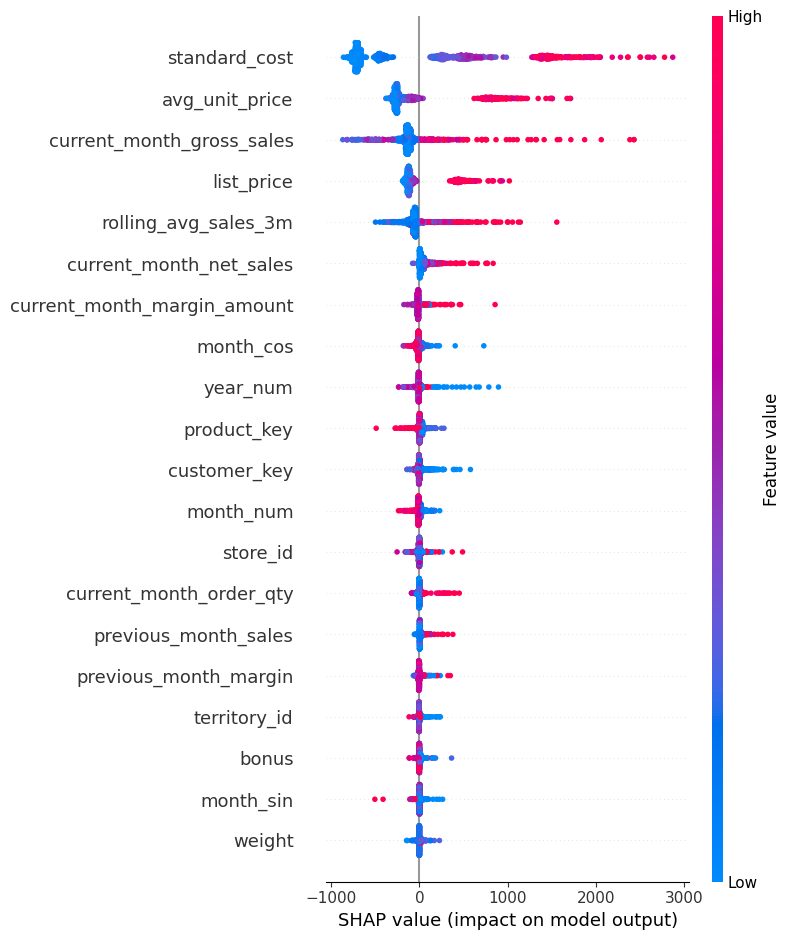

In [35]:
# !pip install shap

import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

best_model = rf_grid.best_estimator_

preprocessor = best_model.named_steps["preprocessor"]
rf_model = best_model.named_steps["model"]

X_train_transformed = preprocessor.transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

# Numeric feature names
numeric_feature_names = numeric_cols

# Categorical encoded feature names
categorical_feature_names = (
    preprocessor
    .named_transformers_["cat"]
    .named_steps["encoder"]
    .get_feature_names_out(categorical_cols)
)

# Combine all final feature names
feature_names = list(numeric_feature_names) + list(categorical_feature_names)

if hasattr(X_test_transformed, "toarray"):
    X_test_transformed = X_test_transformed.toarray()

if hasattr(X_train_transformed, "toarray"):
    X_train_transformed = X_train_transformed.toarray()

X_test_shap = pd.DataFrame(
    X_test_transformed,
    columns=feature_names,
    index=X_test.index
)

X_train_shap = pd.DataFrame(
    X_train_transformed,
    columns=feature_names,
    index=X_train.index
)

X_test_sample = X_test_shap.sample(
    n=min(1000, len(X_test_shap)),
    random_state=42
)

explainer = shap.TreeExplainer(rf_model)

shap_values = explainer.shap_values(X_test_sample)

shap.summary_plot(
    shap_values,
    X_test_sample,
    feature_names=X_test_sample.columns
)

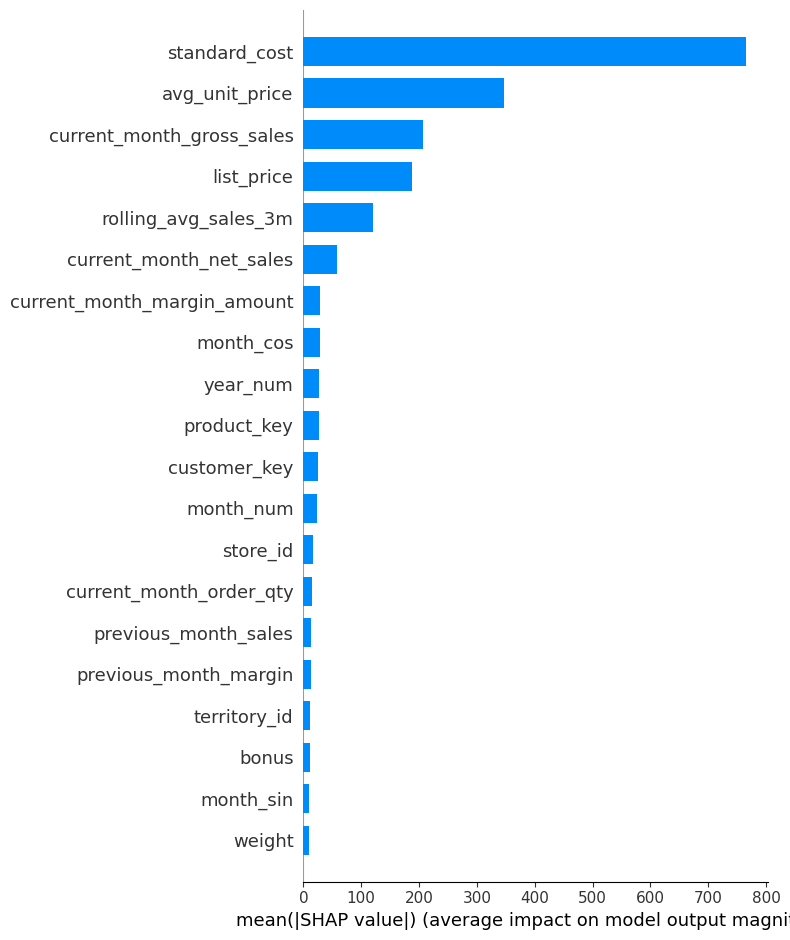

In [36]:
shap.summary_plot(
    shap_values,
    X_test_sample,
    feature_names=X_test_sample.columns,
    plot_type="bar"
)

In [37]:
import joblib
import os

# Create folder to store model artifacts
os.makedirs("model_artifacts", exist_ok=True)

# Save the full pipeline
joblib.dump(
    best_tuned_model,
    "model_artifacts/best_random_forest_pipeline.pkl"
)
joblib.dump(
    X_train.columns.tolist(),
    "model_artifacts/feature_columns.pkl"
)
print("Best model pipeline saved successfully.")

Best model pipeline saved successfully.
